In [1]:
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import replace

import run_config
import utils_lya_halo

from run_config import cfg, smoke
from utils_lya_halo import run_extract, run_stack, read_galaxy_fits, run_measure, plotting, validation, multicat, analysis, io
from utils_lya_halo.stack import build_stacks
from utils_lya_halo.measure import measure_all_bins, integrated_line_flux
from utils_lya_halo import speclsf

# Reading in output and stacking

In [2]:
gal_aegis_filename = './outputs/galaxy_catc1488c_b8_8c91de_AEGIS_MOSDEF_virial_biweight_image_bg57-63.fits'
gal_aegis = read_galaxy_fits(gal_aegis_filename)

gal_cosmos_filename = './outputs/galaxy_catc1488c_b8_8c91de_COSMOS_MOSDEF_virial_biweight_image_bg57-63.fits'
gal_cosmos = read_galaxy_fits(gal_cosmos_filename)

#Combines both to produce a unified PSF (but understand the field-to-field differences ARE real)
product = multicat.combine_products({"AEGIS": gal_aegis, "COSMOS": gal_cosmos})

combined 2 products -> 528 galaxies (origin in column 'SUBSET')


In [10]:
half_window = 4

cfg2 = replace(cfg, 
    field="BOTH",
    bins=[0, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0],
    bin_mode='virial',
    catalog_path="catalogs/lya_halo_catalog_cuts/ALL_haoiii_sn5_mosdef_catalog.txt",
    n_bootstrap=500,
    line_window = [1215.67-half_window, 1215.67+half_window],
    rest_density=True,
    rest_wave_min=1100, rest_wave_max=1300)

stacks = build_stacks(cfg2, product, keep_cube=True)

Capping logMstar 11.37 -> 11.00, z=2.163
Capping logMstar 11.01 -> 11.00, z=2.296
Capping logMstar 11.34 -> 11.00, z=2.297
Capping logMstar 11.34 -> 11.00, z=2.297
Capping logMstar 11.04 -> 11.00, z=2.187
Capping logMstar 11.21 -> 11.00, z=2.471
Capping logMstar 11.18 -> 11.00, z=2.292
Capping logMstar 11.18 -> 11.00, z=2.114
Capping logMstar 11.28 -> 11.00, z=2.365
Capping logMstar 11.07 -> 11.00, z=2.475
Capping logMstar 11.29 -> 11.00, z=2.191
Capping logMstar 11.06 -> 11.00, z=2.562
Capping logMstar 11.11 -> 11.00, z=2.442
Capping logMstar 11.74 -> 11.00, z=2.447
Capping logMstar 11.43 -> 11.00, z=2.102
Capping logMstar 11.23 -> 11.00, z=2.465
Capping logMstar 11.19 -> 11.00, z=2.468
Capping logMstar 11.06 -> 11.00, z=2.472
Capping logMstar 11.06 -> 11.00, z=2.479
Capping logMstar 11.23 -> 11.00, z=2.471
Capping logMstar 11.63 -> 11.00, z=2.487
Capping logMstar 11.30 -> 11.00, z=2.446
Capping logMstar 11.08 -> 11.00, z=3.179


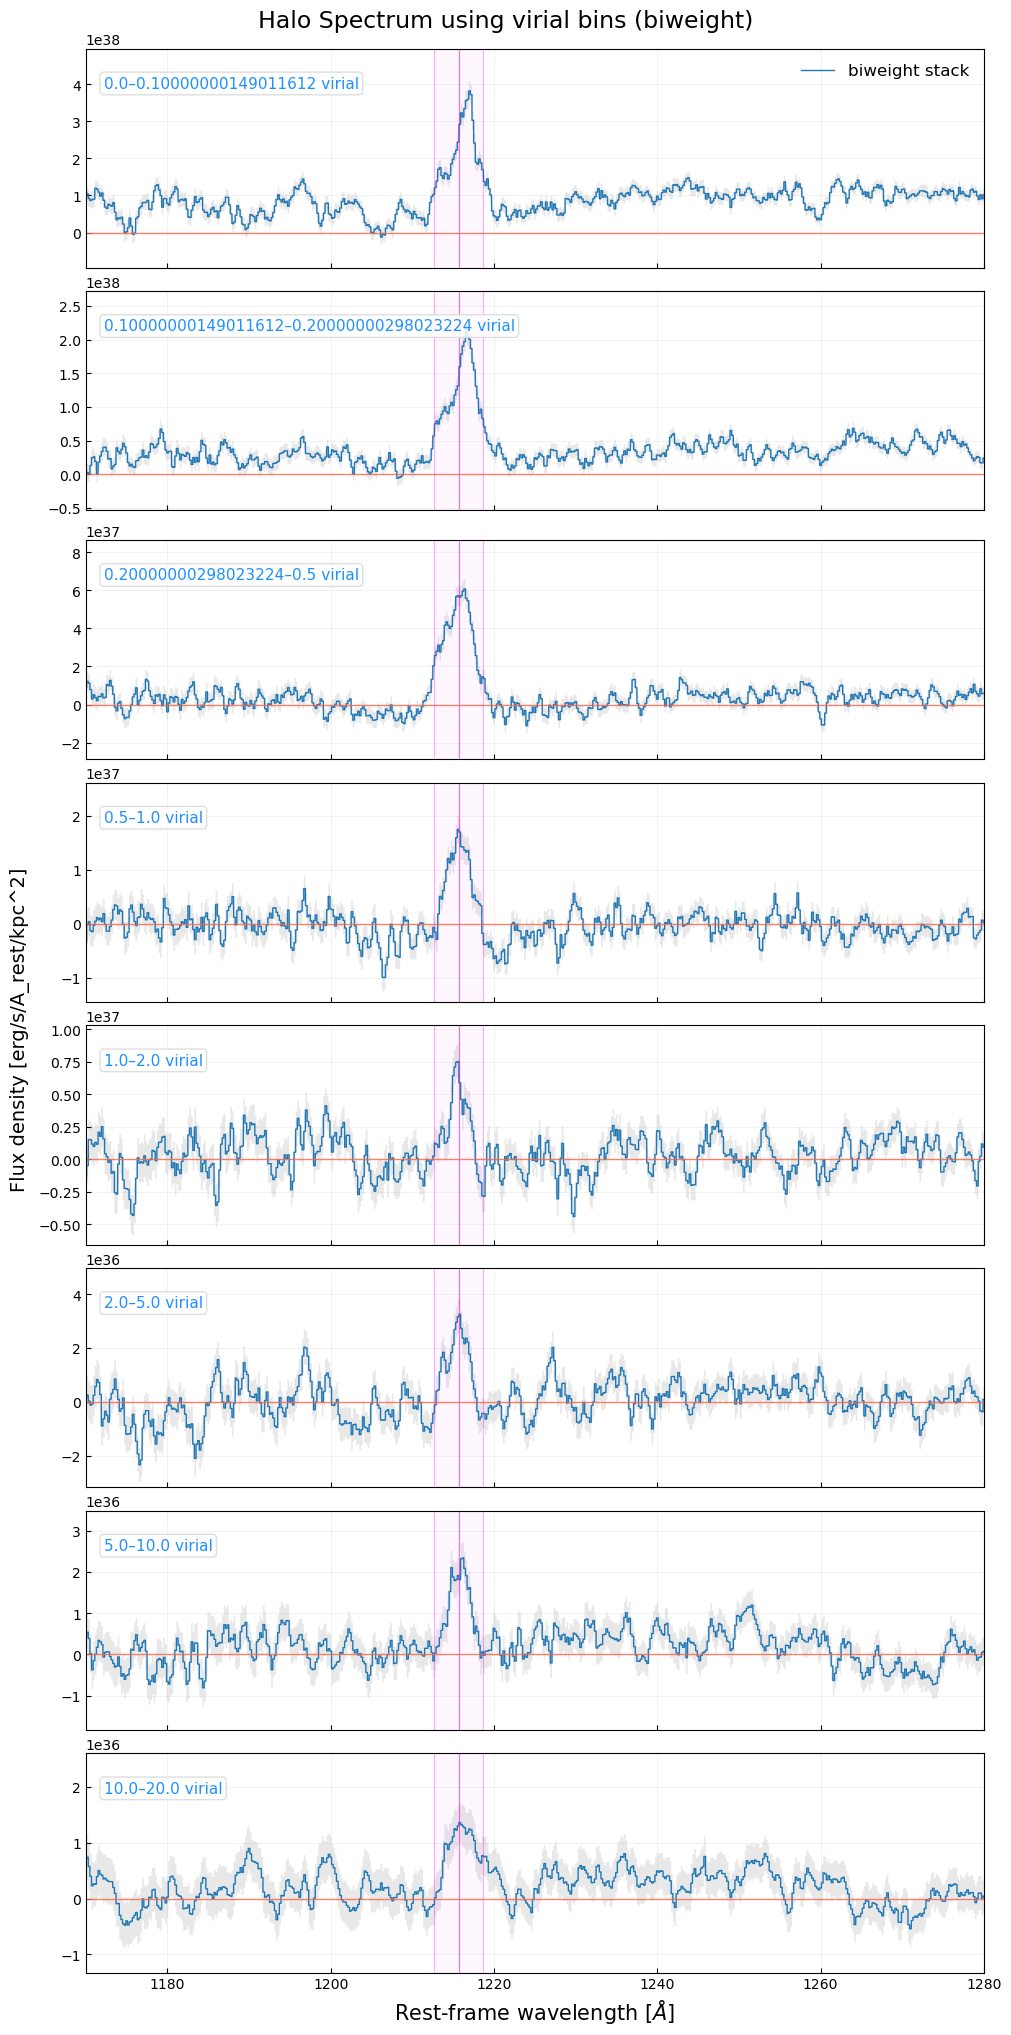

(<Figure size 1000x2000 with 8 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: xlabel='Rest-frame wavelength [$\\AA$]'>],
       dtype=object))

In [11]:
plotting.plot_stack_panels(stacks, 
    method="biweight",
    distance_type="virial",
    title=None,
    xlim=(1170, 1280),
    lya_window=3,
    figsize_width=10,
    panel_height=2.5,
    show_err=True,
    smooth=None,
    savepath=None,
    dpi=300)

# Bootstrap and measure Lya peak compared to LSF

In [12]:
# ---- 0. simple inputs: cfg2, stacks, boot ----
product = io.load_for_stack(cfg2)                 # stack_lsf needs the product, not stacks
lsf  = speclsf.stack_lsf(cfg2, product, z_err_kms=60.0)

Loaded BOTH: 248 AEGIS + 280 COSMOS = 528
Finite-spectrum cut (bin 7, > 100 px): kept 506 / 528 galaxies


/home/jovyan/work/ls6/VIRAL-Halos/astrickler/utils_lya_halo/plotting.py:1386: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


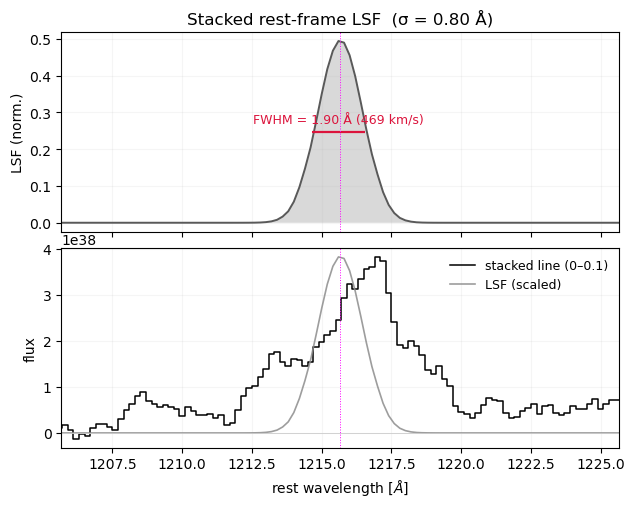

(<Figure size 720x540 with 2 Axes>,
 (<Axes: title={'center': 'Stacked rest-frame LSF  (σ = 0.80 Å)'}, ylabel='LSF (norm.)'>,
  <Axes: xlabel='rest wavelength [$\\AA$]', ylabel='flux'>))

In [13]:
plotting.plot_lsf(lsf, 
    stacks=stacks, 
    radial_bin=0, 
    stack_method="biweight",
    lya_center=1215.67, 
    xlim=None, 
    figsize=(7.2, 5.4),
    save_fig=False, 
    savename="Figure_lsf.png")

In [15]:
boot = analysis.run_measurement_suite(cfg2, stacks)

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]


line moments (fiducial stack, no bootstrap):
  0-0.1: v=+155.4  σ=370.2  skew=-0.390
  0.1-0.2: v=+120.5  σ=389.8  skew=-0.334
  0.2-0.5: v=-29.0  σ=389.4  skew=-0.097
  0.5-1: v=+12.4  σ=296.0  skew=+0.077
  1-2: v=-13.5  σ=288.7  skew=+0.169
  2-5: v=-40.9  σ=265.4  skew=-0.296
  5-10: v=+30.8  σ=242.5  skew=-0.080
  10-20: v=+161.1  σ=356.3  skew=+0.243


In [56]:
bin_num = 0
flux = stacks['stacks'][cfg2.measure_stack_method]['flux'][bin_num]
ferr = boot['stack_error']['stack_err'][bin_num]

In [65]:
peak_guess = None
#dict(blue_offset=-2.0, red_offset=.9, flux_ratio=0.4, sigma=0.9)
window_bounds = 4.5 #A

res = speclsf.deconvolve_intrinsic_profile(
    stacks['rest_wave'], flux, ferr, lsf,
    model='both', 
    bounds_window=window_bounds, 
    baseline=False,
    peak_guess=peak_guess,
    select="ftest", 
    alpha=0.05,
    p0_single=None, 
    verbose=True)

[both] chi2/ndof single=5.67 double=1.82 | F=30.64 p=2.39e-10 dAIC=161.2 dBIC=155.8 -> SELECTED: double (F-test p=2.39e-10 < alpha=0.05)


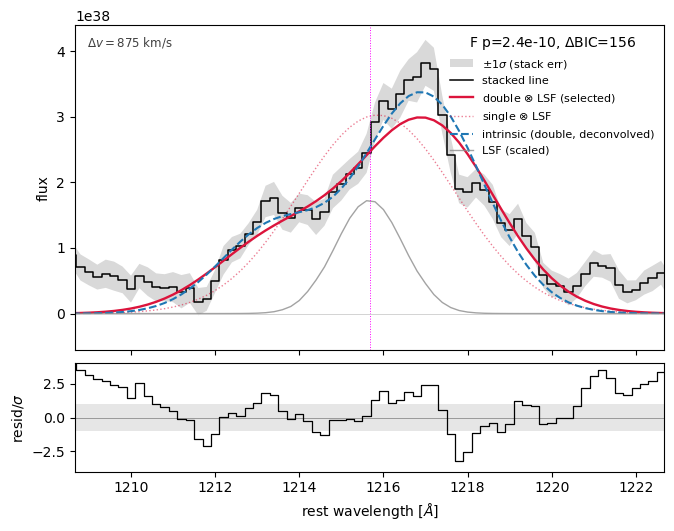

(<Figure size 760x580 with 2 Axes>,
 (<Axes: ylabel='flux'>,
  <Axes: xlabel='rest wavelength [$\\AA$]', ylabel='resid/$\\sigma$'>))

In [66]:
# diagnostic figure (pass bres to annotate the CIs + double_fraction)
plotting.plot_intrinsic_fit(stacks['rest_wave'], flux, ferr, res,
    lsf_result=lsf)

In [31]:
# bootstrap CIs + double-vs-single stability for this bin
bres = speclsf.bootstrap_intrinsic_profile(stacks, lsf, bin_num, ferr, 
                                           config=cfg2,
                                           model='both', 
                                           nboot=500, 
                                           bounds_window=window_bounds)

bootstrap bin 0:   0%|          | 0/500 [00:00<?, ?it/s]

bin 0: 500/500 draws ok; double chosen 87%
  sigma_int = 1.33 [1.22, 1.40] A (329 km/s)  [from single-fit draws]
  peak_sep  = 3.36 [2.86, 3.59] A (828 km/s)  [from double-fit draws]


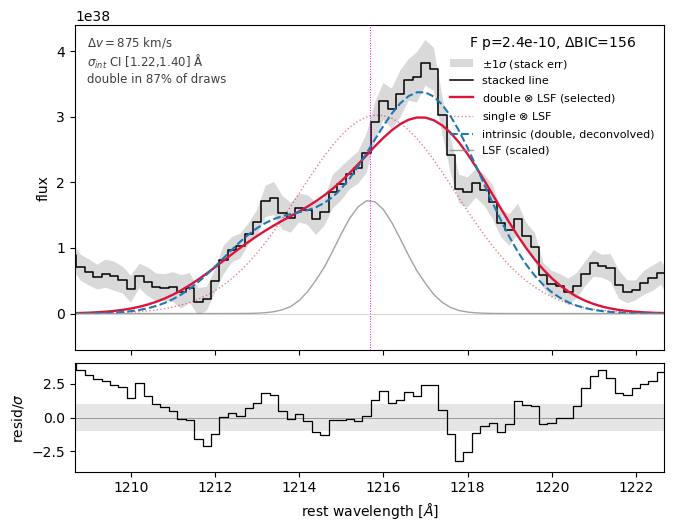

(<Figure size 760x580 with 2 Axes>,
 (<Axes: ylabel='flux'>,
  <Axes: xlabel='rest wavelength [$\\AA$]', ylabel='resid/$\\sigma$'>))

In [32]:
# diagnostic figure (pass bres to annotate the CIs + double_fraction)
plotting.plot_intrinsic_fit(stacks['rest_wave'], flux, ferr, res,
    lsf_result=lsf, 
    boot=bres)

# Manual Testing

In [ ]:
lya_rest = 1215.67

red_offset  = 1.0
blue_offset = -1.9
blue_to_red = 0.45

# Normalize once
lsf_norm = lsf['lsf'] / np.nanmax(lsf['lsf'])

# Shifted components
red_peak  = lsf_norm
blue_peak = lsf_norm * blue_to_red
red_wave  = lsf['rest_wave'] + red_offset
blue_wave = lsf['rest_wave'] + blue_offset

# Common grid (could use stacks['rest_wave'])
wave_grid = stacks['rest_wave']

# Interpolate both peaks onto common grid
red_interp = np.interp(
    wave_grid,
    red_wave,
    red_peak,
    left=0,
    right=0)
blue_interp = np.interp(
    wave_grid,
    blue_wave,
    blue_peak,
    left=0,
    right=0)

# Total model
model = red_interp + blue_interp

In [ ]:
bin_num = 0

# Plot
plt.figure(figsize=(10, 5))
plt.step(red_wave, red_peak, c='tomato', lw=1, label='Red peak')
plt.step(blue_wave, blue_peak, c='cornflowerblue', lw=1, label='Blue peak')
plt.step(wave_grid, model, c='k', lw=1.5, label='Sum')

plt.step(
    stacks['rest_wave'],
    stacks['stacks']['biweight']['flux'][bin_num] /
    np.nanmax(stacks['stacks']['biweight']['flux'][bin_num]),
    c='green',
    label='Data')

plt.axvline(lya_rest, c='magenta', lw=1)
plt.axhline(0, c='k', lw=1)

plt.title("Blue and Red LSF peaks - Instrumental vs Observed width")
plt.xlim(1200, 1232)
plt.legend()